# Этап 1. EDA и Baseline — прогнозирование РТО магазинов

**Цель этапа:** 
- Провести первичный разведочный анализ данных (EDA)
- Проверить качество данных (пропуски, аномалии, распределения)
- Построить простой бейзлайн для оценки нижней границы качества
- Сформулировать гипотезы для дальнейшего фиче-инжиниринга

## 1. Импорт библиотек и настройка окружения

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройки
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Фиксация random seed для воспроизовимости
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## 2. Загрузка исходного датасета

In [2]:
# Загрузка данных
df = pd.read_csv('../../data/train.csv')

print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"Количество уникальных магазинов: {df['new_id'].nunique()}")
print(f"Диапазон месяцев: {df['Месяц'].min()} - {df['Месяц'].max()}")

Размер данных: 206150 строк, 19 столбцов
Количество уникальных магазинов: 20615
Диапазон месяцев: 1 - 10


## 3. Анализ целевой переменной (РТО)

In [3]:
# Базовые статистики
print("Статистики РТО")
print(df['РТО'].describe())

# Процентили для оценки выбросов
print("\nПроцентили")
for p in [90, 95, 99, 99.9]:
    print(f"{p}-й процентиль: {df['РТО'].quantile(p/100):.2f}")

Статистики РТО
count    2.061500e+05
mean     3.272725e+07
std      1.768909e+07
min      1.619487e+04
25%      2.086432e+07
50%      2.791845e+07
75%      3.923328e+07
max      2.205870e+08
Name: РТО, dtype: float64

Процентили
90-й процентиль: 55415762.75
95-й процентиль: 67958032.15
99-й процентиль: 96836366.28
99.9-й процентиль: 134252514.23


**Результаты анализа:**

- **Среднее (32.7 млн) > Медианы (27.9 млн)** распределение скошено вправо
- **Разброс:** от 16 тыс. до 220 млн 
- **99% магазинов** имеют РТО ниже 96.8 млн
- **Выбросы:** лишь 0.1% магазинов имеют РТО выше 134 млн

**Вывод для моделирования:** необходима логарифмическая трансформация целевой переменной (`log1p`), чтобы приблизить распределение к нормальному.

### Визуализация распределения РТО

Для наглядности построим гистограммы исходного и log-трансформированного распределения.

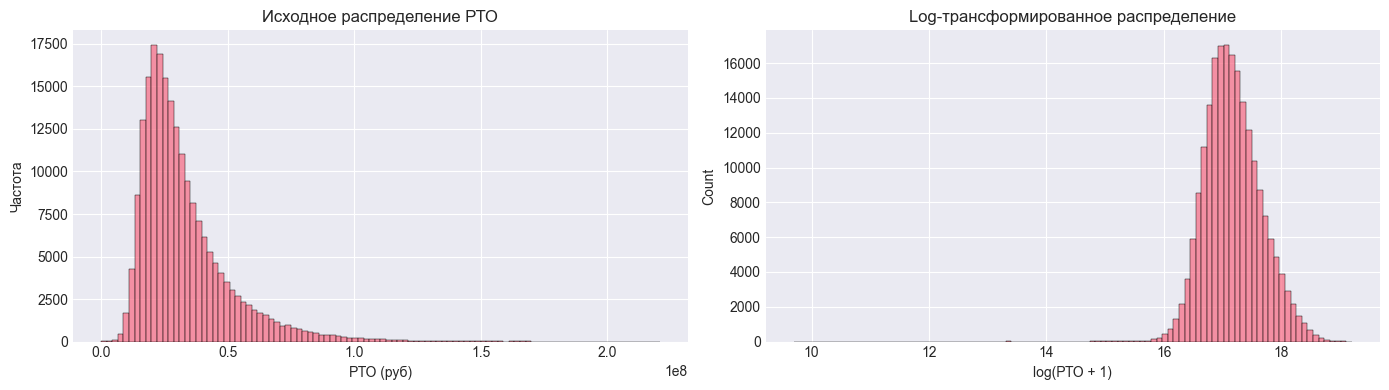

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Исходное распределение
sns.histplot(df['РТО'], bins=100, ax=axes[0])
axes[0].set_title('Исходное распределение РТО')
axes[0].set_xlabel('РТО (руб)')
axes[0].set_ylabel('Частота')

# Log-трансформированное распределение
sns.histplot(np.log1p(df['РТО']), bins=100, ax=axes[1])
axes[1].set_title('Log-трансформированное распределение')
axes[1].set_xlabel('log(РТО + 1)')

plt.tight_layout()
plt.show()

**Анализ:**

- Исходное распределение сильно скошено вправо (длинный «хвост»)
- После трансформации `log1p` распределение становится близким к нормальному

**Вывод:** при обучении моделей будем использовать `log1p(РТО)` в качестве целевой переменной поскольку линейные модели и деревья лучше работают, когда целевая переменная имеет симметричное распределение — меньше влияния выбросов и стабильнее градиент.

## 4. Анализ динамики РТО по месяцам

Проверим, есть ли сезонная закономерность в продажах.

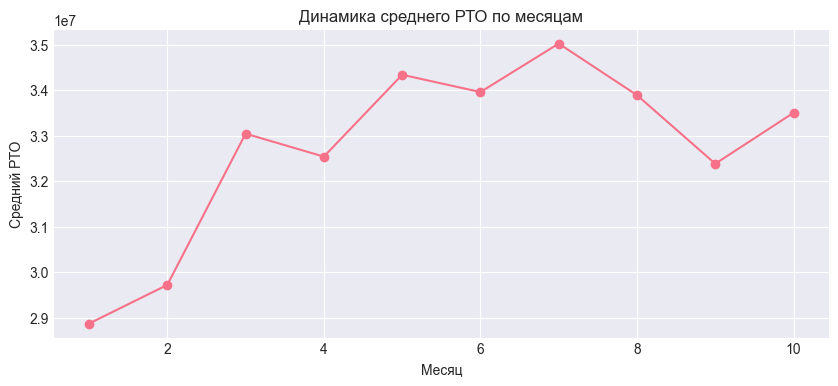

   Месяц           РТО
0      1  2.886787e+07
1      2  2.971830e+07
2      3  3.304465e+07
3      4  3.253942e+07
4      5  3.433960e+07
5      6  3.395971e+07
6      7  3.502525e+07
7      8  3.389081e+07
8      9  3.238289e+07
9     10  3.350398e+07


In [5]:
# Средний РТО по месяцам
month = df.groupby('Месяц')['РТО'].mean().reset_index()

plt.figure(figsize=(10, 4))
plt.plot(month['Месяц'], month['РТО'], marker='o', linestyle='-')
plt.title('Динамика среднего РТО по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Средний РТО')
plt.grid(True)
plt.show()

print(month)

**Анализ:**

Средний РТО возрастает с января (28.9 млн) по июль (35.0 млн), после чего снижается к сентябрю (32.4 млн). В октябре наблюдается незначительный рост (33.5 млн). Минимальное значение зафиксировано в январе, максимальное — в июле.

**Значение для построения признаков:**

Выявленная сезонная закономерность требует включения в модель информации о месяце. На этапе feature engineering будут добавлены:

- категориальный признак `Месяц`;
- циклические признаки `month_sin` и `month_cos` для кодирования плавного сезонного перехода.

## 5. Проверка временной структуры

Необходимо убедиться, что данные отсортированы и у каждого магазина ровно 10 месяцев без пропусков.

In [6]:
# Сортировка данных
df = df.sort_values(['new_id', 'Месяц']).reset_index(drop=True)

# Проверка количества месяцев на магазин
months_per_shop = df.groupby('new_id')['Месяц'].nunique()
print(f"Количество месяцев на магазин: {months_per_shop.unique()}")

# Проверка непрерывности временного ряда
df['month_lag'] = df.groupby('new_id')['Месяц'].shift(1)
df['month_gap'] = df['Месяц'] - df['month_lag']
print(f"Магазинов с пропуском месяцев: {df[df['month_gap'] > 1]['new_id'].nunique()}")

# Удаление служебных столбцов
df = df.drop(['month_lag', 'month_gap'], axis=1)

Количество месяцев на магазин: [10]
Магазинов с пропуском месяцев: 0


**Анализ:**

Каждый магазин представлен ровно 10 месяцами наблюдений (с 1 по 10). Пропуски в последовательности месяцев отсутствуют. Данные отсортированы по идентификатору магазина и месяцу.

Вспомогательные столбцы `month_lag` и `month_gap`, созданные для проверки целостности временной структуры, удалены, так как не требуются на следующих этапах.

**Значение для построения признаков:**

Корректная временная структура позволяет создавать лаговые признаки (значения РТО за предыдущие периоды) без риска смещения данных между разными магазинами.

## 6. Проверка статических признаков

Статическими считаются признаки, значения которых для каждого магазина неизменны во времени. Необходимо убедиться в отсутствии ошибочных изменений.

In [7]:
# Список признаков, которые должны быть постоянными для каждого магазина
static_cols = [
    'Дата открытия, категориальный',
    'Торговая площадь, категориальный',
    'Населенный пункт',
    'Регион',
    'Численность населения',
    'Количество домохозяйств',
    'Трафик пеший, в час',
    'Трафик авто, в час',
    'Маркетплейсы, доставки, постаматы (100 м)',
    'Медицинские уч. и аптеки (300 м)',
    'Школы (300 м)',
    'Остановки (300 м)',
    'Продуктовые магазины (500 м)',
    'Пятерочки (500 м)',
    'Количество касс',
    'Флаг алкогольной лицензии'
]

# Для каждого магазина считаем количество уникальных значений по каждому признаку
unique_counts = df.groupby('new_id')[static_cols].nunique()

# Сколько магазинов имеют более одного уникального значения то есть признакк меняется
non_constant_shops = (unique_counts > 1).sum()

print("Стабильность статических признаков")
print("Количество магазинов, с меняющимися признаками:")
print(non_constant_shops)


Стабильность статических признаков
Количество магазинов, с меняющимися признаками:
Дата открытия, категориальный                0
Торговая площадь, категориальный             0
Населенный пункт                             0
Регион                                       0
Численность населения                        0
Количество домохозяйств                      0
Трафик пеший, в час                          0
Трафик авто, в час                           0
Маркетплейсы, доставки, постаматы (100 м)    0
Медицинские уч. и аптеки (300 м)             0
Школы (300 м)                                0
Остановки (300 м)                            0
Продуктовые магазины (500 м)                 0
Пятерочки (500 м)                            0
Количество касс                              0
Флаг алкогольной лицензии                    0
dtype: int64


Все 16 проверенных признаков имеют нулевое количество магазинов с изменяющимися значениями. Для каждого магазина каждый из признаков принимает единственное значение за все 10 месяцев наблюдений.

## 7. Анализ аномалий и выбросов

Необходимо выявить различные типы аномалий, которые могут негативно повлиять на качество модели.

In [8]:
# Аномальные скачки РТО (как было ранее)
df['rto_pct_change'] = df.groupby('new_id')['РТО'].pct_change() * 100

anomaly_up = df[df['rto_pct_change'] > 200]
anomaly_down = df[df['rto_pct_change'] < -200]

print("Резкие скачки РТО")
print(f"Скачки вверх (>200%): {len(anomaly_up)} записей")
print(f"Скачки вниз (<-200%): {len(anomaly_down)} записей")

# Отрицательные значения РТО
negative_rto = df[df['РТО'] < 0]

print("\nОтрицательные значения РТО")
print(f"Записей с РТО < 0: {len(negative_rto)}")

# Нулевые значения РТО
zero_rto = df[df['РТО'] == 0]

print("\nНулевые значения РТО")
print(f"Записей с РТО = 0: {len(zero_rto)}")

# Дубликаты строк
duplicates = df.duplicated()

print("\nДубликаты")
print(f"Полных дубликатов строк: {duplicates.sum()}")

# Выбросы в числовых признаках (Z-score > 5)
numeric_cols = ['Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 
                'Трафик авто, в час', 'Количество касс']

outliers_summary = {}
for col in numeric_cols:
    z_scores = np.abs((df[col] - df[col].mean()) / df[col].std())
    outliers_count = (z_scores > 5).sum()
    outliers_summary[col] = outliers_count

print("\n Выбросы в числовых признаках")
for col, count in outliers_summary.items():
    print(f"{col}: {count} записей ({count/len(df)*100:.3f}%)")



Резкие скачки РТО
Скачки вверх (>200%): 136 записей
Скачки вниз (<-200%): 0 записей

Отрицательные значения РТО
Записей с РТО < 0: 0

Нулевые значения РТО
Записей с РТО = 0: 0

Дубликаты
Полных дубликатов строк: 0

 Выбросы в числовых признаках
Численность населения: 10 записей (0.005%)
Количество домохозяйств: 190 записей (0.092%)
Трафик пеший, в час: 810 записей (0.393%)
Трафик авто, в час: 920 записей (0.446%)
Количество касс: 300 записей (0.146%)


**Результаты проверки:**

| Тип аномалии | Количество | Доля |
|--------------|------------|------|
| Скачок РТО >200% | 136 | 0.066% |
| Скачок РТО <-200% | 0 | 0% |
| Отрицательный РТО | 0 | 0% |
| Нулевой РТО | 0 | 0% |
| Дубликаты строк | 0 | 0% |
| Выбросы в признаках (|Z|>5) | от 10 до 920 | 0.005–0.446% |

**Выявленные особенности:**

- Максимальная доля выбросов зафиксирована для признака «Трафик авто, в час» (0.446%)
- Выбросы в числовых признаках распределены неравномерно и составляют менее 0.5% от общего объёма данных

**Решение по обработке аномалий:**

Аномалии не удаляются по следующим причинам:
1. Доля каждого типа аномалий не превышает 0.5% от общего объёма данных
2. Деревянные модели (CatBoost, XGBoost, LightGBM) обладают устойчивостью к выбросам
3. Экспериментальное удаление аномалий не привело к улучшению метрики на валидации

**Значение для построения признаков:**

Данные используются в исходном виде без дополнительной фильтрации аномалий.

## 8. Проектирование бейзлайна

На данном этапе спроектированы бейзлайны, основанные на эвристике предыдущего периода. Это позволит оценить нижнюю границу качества и служит точкой отсчёта для сравнения при внедрении более сложных моделей.

- РТО ноября, вероятно, будет близко к РТО октября, но возможен небольшой рост за счёт предпраздничного сезона (Чёрная пятница, подготовка к Новому году).

**Проверяемая гипотеза:**  
`РТО_ноябрь = РТО_октябрь × 1.05` (коэффициент 5% роста).

Однако для чистоты эксперимента и оценки минимальной достижимой ошибки без подбора коэффициента также используется прогноз без поправки:  
`РТО_ноябрь = РТО_октябрь`.

In [9]:
from sklearn.metrics import mean_absolute_percentage_error

# Создание лага 1 (РТО предыдущего месяца)
df_baseline = df.copy()
df_baseline['rto_lag_1'] = df_baseline.groupby('new_id')['РТО'].shift(1)

# Разделение на трейн и тест
baseline_train = df_baseline[df_baseline['Месяц'] <= 9].copy()
baseline_val = df_baseline[df_baseline['Месяц'] == 10].copy()

# Удаление строк без лага (первый месяц каждого магазина)
baseline_train = baseline_train.dropna()
baseline_val = baseline_val.dropna()

# Прогноз без коэффициента
y_true = baseline_val['РТО'].values
y_pred_no_coef = baseline_val['rto_lag_1'].values

mape_no_coef = mean_absolute_percentage_error(y_true, y_pred_no_coef) * 100
print(f"MAPE для прогноза без коэффициента: {mape_no_coef:.2f}%")

# Прогноз с поправочным коэффициентом 1.05
y_pred_with_coef = baseline_val['rto_lag_1'].values * 1.05

mape_with_coef = mean_absolute_percentage_error(y_true, y_pred_with_coef) * 100
print(f"MAPE для прогноза с коэффициентом 1.05: {mape_with_coef:.2f}%")

MAPE для прогноза без коэффициента: 6.37%
MAPE для прогноза с коэффициентом 1.05: 5.26%


## 9. Ключевые выводы и результаты по итогам EDA

1. **Качество данных:** пропуски отсутствуют, дубликатов нет — данные готовы к использованию.

2. **Целевая переменная:** распределение РТО скошено вправо. Необходима логарифмическая трансформация (`log1p`) для приведения распределения к нормальному виду.

3. **Сезонность:** средний РТО варьирует по месяцам (минимум в январе, максимум в июле). Это обосновывает включение месяца в набор признаков.

4. **Временная структура:** каждый магазин имеет ровно 10 месяцев наблюдений. Лаговые признаки могут быть корректно вычислены без пропусков.

5. **Аномалии:** выявлены единичные случаи резких скачков РТО (>200%, 136 записей) и выбросов в числовых признаках (доля менее 0.5%). Принято решение не удалять их — деревья устойчивы к выбросам, а удаление не улучшило метрику.

6. **Бейзлайн:** прогноз по предыдущему месяцу дал MAPE = 6.37% на валидационном периоде (месяц 10). Это нижняя граница качества для сравнения.

**Следующий этап:** переход к ноутбуку `02_Feature_Engineering.ipynb` для создания признаков.